# H100 Optuna Search - GATv2 PicSeq

Self-contained Colab notebook for an advanced GATv2 regressor on PicSeq fold `.pkl` files, with subject-aware loss and architecture search.

Optuna maximizes **validation subject-level Pearson r**. Test folds are evaluated only after the best config is selected.

Final Excel reports include Pearson r, Spearman r, p-values, MSE, pooled subject metrics, best config, Optuna trials, and peak VRAM usage. Advanced-v3 outputs are saved separately from older runs.

## 1. Config

In [ ]:
# Drive inputs / outputs
DRIVE_FOLD_DIR     = '/content/drive/MyDrive/gnn-mri-picseq_v2'
DRIVE_OUTPUT_DIR   = '/content/drive/MyDrive/results/picseq_gatv2_h100_optuna'

# Local scratch avoids slow Drive I/O during training.
USE_SCRATCH_DISK   = True
LOCAL_FOLD_DIR     = '/content/local-scratch/folds_picseq'
LOCAL_OUTPUT_DIR   = '/content/local-scratch/picseq_gatv2_h100_optuna'
AVOID_OVERWRITE    = True

# Optuna search settings. Start here, then increase if the first run looks stable.
TARGET_TOTAL_TRIALS = 75
OPTUNA_FOLD_LIMIT  = None    # use all folds for a less noisy, higher-quality Optuna signal
TRIAL_EPOCHS       = 40
TRIAL_PATIENCE     = 8

# Final training with the best config.
FINAL_EPOCHS       = 120
FINAL_PATIENCE     = 20

# H100 / high-RAM tuning
# RAM_SAFETY_MODE prevents CPU RAM blow-ups from fold caching + DataLoader worker copies.
RAM_SAFETY_MODE       = True
MAX_RAM_CACHE_FRACTION = 0.45  # never reserve more than this fraction for cached fold payloads
MAX_RAM_PERCENT_BEFORE_PRUNE = 90.0
DATALOADER_NUM_WORKERS = None  # auto: conservative for PyG object lists
VAL_TEST_NUM_WORKERS   = 0     # validation/test loaders stay in-process to avoid extra graph copies
DATALOADER_PREFETCH    = None  # auto: conservative prefetch
DATALOADER_PERSISTENT_WORKERS = False
BATCH_SIZE_CHOICES     = None  # auto: adapts to GPU VRAM
CACHE_FOLDS_IN_RAM     = None  # auto: cache folds when system RAM is sufficient
PRELOAD_NUM_WORKERS    = None  # auto: parallel CPU fold preload workers
FAST_H100_MODE         = True
USE_TORCH_COMPILE      = False  # PyG dynamic batches can compile slowly; enable only after a successful baseline

# Single-GPU Colab should keep this at 1. Use >1 only with real multi-GPU setup and separate devices.
OPTUNA_N_JOBS = 1

BASE_SEED = 42
NORMALIZE_METHOD = 'standard'
N_ROIS = 268

## 2. Setup Colab, GPU, and Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch_geometric # Ensure torch_geometric is installed

from pathlib import Path
import json
import joblib
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import torch_geometric # Import torch_geometric to ensure its classes are available for torch.load

FOLD_NAME = 'graphs_outer1_inner1'  # <-- change this
PICSEQ_FOLD_DIR = Path('/content/drive/MyDrive/gnn-mri-picseq_v2')
OUTPUT_DIR = Path('/content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest/scalers')

fold_pkl = PICSEQ_FOLD_DIR / f'{FOLD_NAME}.pkl'
scaler_out = OUTPUT_DIR / FOLD_NAME / 'target_scaler.joblib'
meta_out = OUTPUT_DIR / FOLD_NAME / 'target_scaler.json'

payload = torch.load(fold_pkl, map_location='cpu', weights_only=False)

if 'train_graphs' not in payload:
    raise KeyError(f'{fold_pkl} does not contain train_graphs')

targets = []
for row in payload['train_graphs']:
    for graph in row:
        if hasattr(graph, 'pad') and bool(graph.pad):
            continue
        targets.append(float(graph.y.item()))

targets = np.asarray(targets, dtype=float).reshape(-1, 1)

scaler = StandardScaler()
scaler.fit(targets)

scaler_out.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, scaler_out)

meta = {
    'task': 'PicSeq',
    'fold_name': FOLD_NAME,
    'fold_pkl': str(fold_pkl),
    'method': 'standard',
    'n_train_windows': int(targets.shape[0]),
    'original_min': float(targets.min()),
    'original_max': float(targets.max()),
    'original_mean': float(targets.mean()),
    'original_std': float(targets.std()),
    'scaler_file': str(scaler_out),
}

with open(meta_out, 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved scaler: {scaler_out}')
print(f'Saved metadata: {meta_out}')
print(f'PicSeq train target mean/std: {meta["original_mean"]:.6f} / {meta["original_std"]:.6f}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.8 MB/s eta 0:00:00
Saved scaler: /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest/scalers/graphs_outer1_inner1/target_scaler.joblib
Saved metadata: /content/drive/MyDrive/results/picseq_fbnetgen_h100_optuna_latest/scalers/graphs_outer1_inner1/target_scaler.json
PicSeq train target mean/std: 113.101638 / 12.965748


In [ ]:
import os, sys, subprocess, shutil, json, math, time, random, gc
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from datetime import datetime

import torch

assert torch.cuda.is_available(), 'No GPU detected. In Colab: Runtime -> Change runtime type -> GPU.'
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
try:
    import psutil
    ram_gb = psutil.virtual_memory().total / 1e9
except Exception:
    psutil = None
    ram_gb = 0.0
print(f'GPU: {gpu_name} ({vram_gb:.1f} GB VRAM)')
print(f'System RAM: {ram_gb:.1f} GB' if ram_gb else 'System RAM: unknown')
if 'H100' not in gpu_name.upper():
    print('Warning: this notebook is tuned for H100, but it will still run on this GPU.')

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = FAST_H100_MODE
def adaptive_batch_sizes(vram_gb):
    if vram_gb >= 75:   # H100/A100 80GB class
        return [256, 512, 768, 1024]
    if vram_gb >= 45:   # A6000/A40/L40S class
        return [128, 256, 512, 768]
    if vram_gb >= 25:
        return [64, 128, 256, 512]
    return [32, 64, 128, 256]

def get_ram_used_gb():
    if psutil is None:
        return float('nan')
    return psutil.virtual_memory().used / 1e9

def print_ram(label):
    if psutil is not None:
        vm = psutil.virtual_memory()
        print(f'{label} RAM used={vm.used/1e9:.1f} GB ({vm.percent:.1f}%), available={vm.available/1e9:.1f} GB')

cpu_count = os.cpu_count() or 2
if DATALOADER_NUM_WORKERS is None:
    # PyG keeps Python graph objects in each worker; too many workers can copy huge fold lists.
    if RAM_SAFETY_MODE:
        DATALOADER_NUM_WORKERS = 2 if ram_gb < 96 else 4
    else:
        DATALOADER_NUM_WORKERS = min(8, max(2, cpu_count // 2))
if DATALOADER_PREFETCH is None:
    DATALOADER_PREFETCH = 2 if RAM_SAFETY_MODE else (4 if ram_gb >= 80 else 2)
if BATCH_SIZE_CHOICES is None:
    BATCH_SIZE_CHOICES = adaptive_batch_sizes(vram_gb)
if CACHE_FOLDS_IN_RAM is None:
    CACHE_FOLDS_IN_RAM = False if RAM_SAFETY_MODE else ((ram_gb == 0.0) or (ram_gb >= 128))

print(f'RAM safety mode: {RAM_SAFETY_MODE}')
print(f'DataLoader workers: train={DATALOADER_NUM_WORKERS}, val/test={VAL_TEST_NUM_WORKERS}, prefetch={DATALOADER_PREFETCH}, persistent={DATALOADER_PERSISTENT_WORKERS}')
print(f'Batch-size search choices: {BATCH_SIZE_CHOICES}')
print(f'Cache folds in RAM: {CACHE_FOLDS_IN_RAM}')
print_ram('Initial')

AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
USE_BF16 = AMP_DTYPE == torch.bfloat16
print(f'AMP dtype: {AMP_DTYPE}')

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (102.0 GB VRAM)
System RAM: 189.9 GB
RAM safety mode: True
DataLoader workers: train=4, val/test=0, prefetch=2, persistent=False
Batch-size search choices: [256, 512, 768, 1024]
Cache folds in RAM: False
Initial RAM used=2.4 GB (2.1%), available=186.0 GB
AMP dtype: torch.bfloat16


In [ ]:
# Install dependencies matched to the active Colab torch/CUDA build.
# If Colab already has them, pip will be quick.
torch_ver = torch.__version__.split('+')[0]
cuda_ver = 'cu' + torch.version.cuda.replace('.', '')
pyg_url = f'https://data.pyg.org/whl/torch-{torch_ver}+{cuda_ver}.html'
print(f'Installing PyG for torch={torch_ver}+{cuda_ver}')

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna', 'pandas', 'scikit-learn', 'scipy', 'openpyxl'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch-geometric'])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyg-lib', 'torch-scatter', 'torch-sparse', 'torch-cluster', 'torch-spline-conv', '-f', pyg_url])

import optuna
print('Optuna:', optuna.__version__)

Installing PyG for torch=2.10.0+cu128
Optuna: 4.8.0


## 3. Prepare Folds and Output Folders

In [ ]:
def unique_dir(path: Path) -> Path:
    path = Path(path)
    if path.exists() and any(path.iterdir()) and AVOID_OVERWRITE:
        stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        path = path.with_name(f'{path.name}_{stamp}')
    path.mkdir(parents=True, exist_ok=True)
    return path

DRIVE_FOLD_PATH = Path(DRIVE_FOLD_DIR)
assert DRIVE_FOLD_PATH.exists(), f'Fold directory not found: {DRIVE_FOLD_PATH}'

drive_out = unique_dir(Path(DRIVE_OUTPUT_DIR))
if USE_SCRATCH_DISK:
    local_fold_path = Path(LOCAL_FOLD_DIR)
    local_fold_path.mkdir(parents=True, exist_ok=True)
    fold_srcs = sorted(DRIVE_FOLD_PATH.glob('graphs_*.pkl'))
    missing_or_stale = [
        fp for fp in fold_srcs
        if not (local_fold_path / fp.name).exists()
        or (local_fold_path / fp.name).stat().st_size != fp.stat().st_size
    ]
    if missing_or_stale:
        copy_workers = min(8, max(1, len(missing_or_stale)), max(2, (os.cpu_count() or 2) // 2))
        print(f'Copying {len(missing_or_stale)} missing/stale fold pkls to local scratch with {copy_workers} worker(s): {local_fold_path}')

        def copy_fold(fp):
            dst = local_fold_path / fp.name
            shutil.copy2(fp, dst)
            return fp.name, fp.stat().st_size / 1e6

        with ThreadPoolExecutor(max_workers=copy_workers) as ex:
            futures = [ex.submit(copy_fold, fp) for fp in missing_or_stale]
            for fut in as_completed(futures):
                name, size_mb = fut.result()
                print(f'  {name} ({size_mb:.1f} MB)')
    else:
        print('All fold pkls already present on local scratch with matching file sizes.')
    save_dir = Path(LOCAL_OUTPUT_DIR)
    save_dir.mkdir(parents=True, exist_ok=True)
else:
    local_fold_path = DRIVE_FOLD_PATH
    save_dir = drive_out

fold_files = sorted(local_fold_path.glob('graphs_*.pkl'))
assert fold_files, f'No graphs_*.pkl files found in {local_fold_path}'
total_fold_pkl_gb = sum(fp.stat().st_size for fp in fold_files) / 1e9
estimated_cache_gb = total_fold_pkl_gb * 3.0  # torch.load + flattened lists + normalized graph copies/headroom
if CACHE_FOLDS_IN_RAM and ram_gb and estimated_cache_gb > ram_gb * MAX_RAM_CACHE_FRACTION:
    print(f'Disabling fold RAM cache: estimated cache {estimated_cache_gb:.1f} GB exceeds {MAX_RAM_CACHE_FRACTION:.0%} of system RAM.')
    CACHE_FOLDS_IN_RAM = False
print(f'Found {len(fold_files)} fold(s), total pkl size={total_fold_pkl_gb:.1f} GB, estimated cache footprint={estimated_cache_gb:.1f} GB:')
for fp in fold_files:
    print(f'  {fp.name} ({fp.stat().st_size/1e9:.2f} GB)')
print(f'Working output: {save_dir}')
print(f'Final Drive output: {drive_out}')

Copying 5 missing/stale fold pkls to local scratch with 5 worker(s): /content/local-scratch/folds_picseq
  graphs_outer1_inner1.pkl (19005.0 MB)
  graphs_outer1_inner5.pkl (19005.0 MB)
  graphs_outer1_inner2.pkl (19005.0 MB)
  graphs_outer1_inner4.pkl (19005.0 MB)
  graphs_outer1_inner3.pkl (19005.0 MB)
Found 5 fold(s), total pkl size=95.0 GB, estimated cache footprint=285.1 GB:
  graphs_outer1_inner1.pkl (19.00 GB)
  graphs_outer1_inner2.pkl (19.00 GB)
  graphs_outer1_inner3.pkl (19.00 GB)
  graphs_outer1_inner4.pkl (19.00 GB)
  graphs_outer1_inner5.pkl (19.00 GB)
Working output: /content/local-scratch/picseq_gatv2_h100_optuna
Final Drive output: /content/drive/MyDrive/results/picseq_gatv2_h100_optuna_20260503_132446


## 3.5. Sanity Check: Target Distribution + Simple Baselines

Before training a GATv2 GNN, get the floor numbers:

* **Target spread** — std of `PicSeq_Unadj` across subjects.
* **Mean predictor** — predicting the training mean for every test subject (this is the floor).
* **Ridge on flattened LDW** — closed-form linear regression on the (268x268) connectivity matrix. If GATv2 doesn't beat Ridge, the GNN isn't earning its complexity.

These numbers give the GATv2 result the right context.

Target distribution per fold (PicSeq_Unadj)
  graphs_outer1_inner1: n=(tr 116, va 30, te 37), train_y mean=+113.10 std=12.97, Ridge test r=+0.314, MSE=200.418
  graphs_outer1_inner2: n=(tr 117, va 29, te 37), train_y mean=+113.81 std=13.85, Ridge test r=+0.136, MSE=235.445
  graphs_outer1_inner3: n=(tr 117, va 29, te 37), train_y mean=+112.41 std=13.78, Ridge test r=+0.210, MSE=219.578
  graphs_outer1_inner4: n=(tr 117, va 29, te 37), train_y mean=+112.93 std=13.18, Ridge test r=+0.169, MSE=219.569
  graphs_outer1_inner5: n=(tr 117, va 29, te 37), train_y mean=+111.75 std=14.06, Ridge test r=+0.112, MSE=236.920

Mean Ridge test r across folds: +0.1882 +/- 0.0792
(GATv2 has to beat this to justify the GNN.)
Saved baselines to: /content/local-scratch/picseq_gatv2_h100_optuna/baselines_per_fold.csv


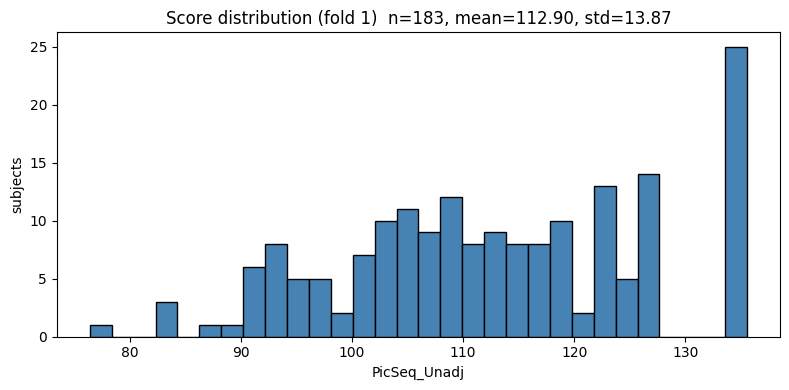

In [ ]:
import numpy as np
import pandas as pd
import torch as _torch
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr

print('=' * 70)
print('Target distribution per fold (PicSeq_Unadj)')
print('=' * 70)

def _per_subject_score_and_lt(graphs2d):
    R = 268
    iu = np.triu_indices(R, k=1)
    rows_x, rows_y = [], []
    for subj_idx, row in enumerate(graphs2d):
        win_xs = []
        for g in row:
            if hasattr(g, 'pad') and bool(g.pad):
                continue
            x = g.x.float().cpu().numpy()
            win_xs.append(x[iu])
        if not win_xs:
            continue
        rows_x.append(np.mean(win_xs, axis=0))
        rows_y.append(float(row[0].y.item()))
    return np.array(rows_x), np.array(rows_y)

baseline_rows = []
for fp in fold_files:
    fold_name = fp.stem
    payload = _torch.load(fp, map_location='cpu', weights_only=False)
    train_x, train_y = _per_subject_score_and_lt(payload['train_graphs'])
    val_x,   val_y   = _per_subject_score_and_lt(payload['val_graphs'])
    test_x,  test_y  = _per_subject_score_and_lt(payload['test_graphs'])

    train_mean = train_y.mean()
    floor_mse = float(np.mean((train_mean - test_y) ** 2))
    sc = StandardScaler()
    train_x_s = sc.fit_transform(train_x)
    test_x_s  = sc.transform(test_x)
    ridge = Ridge(alpha=1.0).fit(train_x_s, train_y)
    ridge_pred = ridge.predict(test_x_s)
    if test_y.std() > 0 and ridge_pred.std() > 0:
        ridge_r  = float(pearsonr(ridge_pred, test_y)[0])
        ridge_sr = float(spearmanr(ridge_pred, test_y)[0])
    else:
        ridge_r = ridge_sr = float('nan')
    ridge_mse = float(np.mean((ridge_pred - test_y) ** 2))

    baseline_rows.append({
        'fold': fold_name,
        'n_train_subj': len(train_y),
        'n_val_subj':   len(val_y),
        'n_test_subj':  len(test_y),
        'train_y_mean': float(train_y.mean()),
        'train_y_std':  float(train_y.std()),
        'test_y_mean':  float(test_y.mean()),
        'test_y_std':   float(test_y.std()),
        'mean_pred_test_mse':   floor_mse,
        'ridge_test_pearson_r':  ridge_r,
        'ridge_test_spearman_r': ridge_sr,
        'ridge_test_mse':  ridge_mse,
    })
    print(f'  {fold_name}: '
          f'n=(tr {len(train_y)}, va {len(val_y)}, te {len(test_y)}), '
          f'train_y mean={train_y.mean():+.2f} std={train_y.std():.2f}, '
          f'Ridge test r={ridge_r:+.3f}, MSE={ridge_mse:.3f}')
    del payload, train_x, train_y, val_x, val_y, test_x, test_y, train_x_s, test_x_s, ridge, ridge_pred
    gc.collect()

baseline_df = pd.DataFrame(baseline_rows)
baseline_csv = save_dir / 'baselines_per_fold.csv'
baseline_df.to_csv(baseline_csv, index=False)
print()
print(f'Mean Ridge test r across folds: {baseline_df["ridge_test_pearson_r"].mean():+.4f} +/- {baseline_df["ridge_test_pearson_r"].std():.4f}')
print(f'(GATv2 has to beat this to justify the GNN.)')
print(f'Saved baselines to: {baseline_csv}')

try:
    import matplotlib.pyplot as plt
    payload0 = _torch.load(fold_files[0], map_location='cpu', weights_only=False)
    _, train_y0 = _per_subject_score_and_lt(payload0['train_graphs'])
    _, val_y0   = _per_subject_score_and_lt(payload0['val_graphs'])
    _, test_y0  = _per_subject_score_and_lt(payload0['test_graphs'])
    all_y = np.concatenate([train_y0, val_y0, test_y0])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(all_y, bins=30, color='steelblue', edgecolor='black')
    ax.set_xlabel('PicSeq_Unadj'); ax.set_ylabel('subjects')
    ax.set_title(f'Score distribution (fold 1)  n={len(all_y)}, mean={all_y.mean():.2f}, std={all_y.std():.2f}')
    plt.tight_layout()
    plt.savefig(save_dir / 'target_distribution.png', dpi=150)
    plt.show()
    plt.close()
    del payload0, train_y0, val_y0, test_y0, all_y
    gc.collect()
except Exception as e:
    print(f'Could not plot histogram: {e}')


## 4. GATv2 Model, Data Utilities, and Metrics

In [ ]:
import math
import random
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr
from torch_geometric.nn import GATv2Conv, GraphNorm, global_mean_pool, global_add_pool, global_max_pool
from torch_geometric.utils import dropout_edge, softmax as pyg_softmax
from torch_geometric.loader import DataLoader

class ImprovedGATv2Regressor(nn.Module):
    def __init__(
        self,
        in_dim,
        hidden_dim=128,
        n_layers=3,
        n_heads=4,
        dropout=0.25,
        edge_dropout=0.1,
        use_edge_attr=True,
        norm_type='layer',
        readout='mean_attn_max',
        input_layers=1,
        residual_alpha=1.0,
        edge_gate=True,
        edge_mix_alpha=0.25,
        edge_temperature=1.0,
        jk_mode='last',
    ):
        super().__init__()
        assert hidden_dim % n_heads == 0, 'hidden_dim must be divisible by n_heads'
        self.edge_dropout = float(edge_dropout)
        self.use_edge_attr = use_edge_attr
        self.norm_type = norm_type
        self.readout = readout
        self.residual_alpha = float(residual_alpha)
        self.edge_gate = bool(edge_gate and use_edge_attr)
        self.edge_mix_alpha = float(edge_mix_alpha)
        self.edge_temperature = float(edge_temperature)
        self.jk_mode = jk_mode
        edge_dim = 1 if use_edge_attr else None

        if int(input_layers) >= 2:
            self.input_proj = nn.Sequential(
                nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            )
        else:
            self.input_proj = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(), nn.Dropout(dropout))

        if self.edge_gate:
            self.edge_q = nn.Linear(hidden_dim, hidden_dim // 2)
            self.edge_k = nn.Linear(hidden_dim, hidden_dim // 2)
            self.edge_scorer = nn.Linear(hidden_dim // 2, 1)

        self.gat_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            self.gat_layers.append(GATv2Conv(hidden_dim, hidden_dim // n_heads, heads=n_heads, concat=True, dropout=dropout, edge_dim=edge_dim))
            if norm_type == 'graph':
                self.norms.append(GraphNorm(hidden_dim))
            elif norm_type == 'none':
                self.norms.append(nn.Identity())
            else:
                self.norms.append(nn.LayerNorm(hidden_dim))

        self.pool_gate = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, 1))
        readout_dim = hidden_dim * {'mean': 1, 'mean_attn': 2, 'mean_attn_max': 3}.get(readout, 3)
        self.head = nn.Sequential(
            nn.Linear(readout_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def _apply_norm(self, norm, x, batch):
        if isinstance(norm, GraphNorm):
            return norm(x, batch)
        return norm(x)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = data.edge_attr if self.use_edge_attr and hasattr(data, 'edge_attr') else None
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(-1)
        x = self.input_proj(x)

        if self.edge_gate and edge_attr is not None and edge_index.size(1) > 0:
            src, dst = edge_index[0], edge_index[1]
            gate = torch.sigmoid(self.edge_scorer(self.edge_q(x[src]) * self.edge_k(x[dst])) / max(self.edge_temperature, 1e-3))
            refined = edge_attr * gate
            edge_attr = self.edge_mix_alpha * edge_attr + (1.0 - self.edge_mix_alpha) * refined

        if self.training and self.edge_dropout > 0:
            edge_index, edge_mask = dropout_edge(edge_index, p=self.edge_dropout, training=True)
            if edge_attr is not None:
                edge_attr = edge_attr[edge_mask]

        layer_outputs = []
        for gat, norm in zip(self.gat_layers, self.norms):
            x_res = x
            x_new = gat(x, edge_index, edge_attr=edge_attr)
            x_new = self._apply_norm(norm, F.elu(x_new), batch)
            x = x_new + self.residual_alpha * x_res
            layer_outputs.append(x)
        if self.jk_mode == 'mean' and len(layer_outputs) > 1:
            x = torch.stack(layer_outputs, dim=0).mean(dim=0)

        with torch.amp.autocast('cuda', enabled=False):
            x = x.float()
            parts = [global_mean_pool(x, batch)]
            if self.readout in {'mean_attn', 'mean_attn_max'}:
                weights = pyg_softmax(self.pool_gate(x).squeeze(-1), batch).unsqueeze(-1)
                parts.append(global_add_pool(x * weights, batch))
            if self.readout == 'mean_attn_max':
                parts.append(global_max_pool(x, batch))
            out = self.head(torch.cat(parts, dim=-1))
        return out.squeeze(-1)

def normalize_targets(scores, method='standard', scaler=None, fit=True):
    arr = np.asarray(scores, dtype=float).reshape(-1, 1)
    if scaler is None:
        if method == 'standard': scaler = StandardScaler()
        elif method == 'minmax': scaler = MinMaxScaler(feature_range=(-1, 1))
        elif method == 'robust': scaler = RobustScaler()
        else: raise ValueError(f'Unknown normalize method: {method}')
    out = scaler.fit_transform(arr) if fit else scaler.transform(arr)
    return out.flatten(), scaler

def flatten_graph_array(arr2d):
    flat, targets, sids = [], [], []
    for subj_idx, row in enumerate(arr2d):
        for g in row:
            if hasattr(g, 'pad') and bool(g.pad):
                continue
            g.subject_id = torch.tensor([subj_idx], dtype=torch.long)
            flat.append(g); targets.append(float(g.y.item())); sids.append(subj_idx)
    return flat, np.asarray(targets), np.asarray(sids)

FOLD_CACHE = {}

def load_graphs_with_normalization(fold_path, normalize_method='standard'):
    fold_path = str(fold_path); cache_key = (fold_path, normalize_method)
    if CACHE_FOLDS_IN_RAM and cache_key in FOLD_CACHE:
        return FOLD_CACHE[cache_key]
    print(f'Loading fold: {Path(fold_path).name}')
    graphs = torch.load(fold_path, map_location='cpu', weights_only=False)
    train_list, train_t, train_sids = flatten_graph_array(graphs['train_graphs'])
    val_list, val_t, val_sids = flatten_graph_array(graphs['val_graphs'])
    test_list, test_t, test_sids = flatten_graph_array(graphs['test_graphs'])
    train_n, scaler = normalize_targets(train_t, method=normalize_method, fit=True)
    val_n, _ = normalize_targets(val_t, method=normalize_method, scaler=scaler, fit=False)
    test_n, _ = normalize_targets(test_t, method=normalize_method, scaler=scaler, fit=False)
    for i,g in enumerate(train_list): g.y = torch.tensor(train_n[i], dtype=torch.float32)
    for i,g in enumerate(val_list): g.y = torch.tensor(val_n[i], dtype=torch.float32)
    for i,g in enumerate(test_list): g.y = torch.tensor(test_n[i], dtype=torch.float32)
    payload = (train_list, val_list, test_list, {'scaler': scaler, 'train_subject_ids': train_sids, 'val_subject_ids': val_sids, 'test_subject_ids': test_sids})
    if CACHE_FOLDS_IN_RAM:
        FOLD_CACHE[cache_key] = payload
    del graphs
    gc.collect()
    print(f'  windows train={len(train_list)} val={len(val_list)} test={len(test_list)}')
    return payload

class SubjectBatchSampler:
    def __init__(self, graphs, max_graphs_per_batch=256, shuffle=True, seed=42):
        self.graphs = graphs
        self.max_graphs_per_batch = int(max_graphs_per_batch)
        self.shuffle = shuffle
        self.seed = seed
        self.epoch = 0
        groups = {}
        for idx, g in enumerate(graphs):
            sid = int(g.subject_id.view(-1)[0].item()) if hasattr(g, 'subject_id') else idx
            groups.setdefault(sid, []).append(idx)
        self.groups = groups
        self.subject_ids = list(groups.keys())

    def __iter__(self):
        rng = random.Random(self.seed + self.epoch)
        self.epoch += 1
        subject_ids = self.subject_ids.copy()
        if self.shuffle:
            rng.shuffle(subject_ids)
        batch = []
        for sid in subject_ids:
            idxs = self.groups[sid].copy()
            if self.shuffle:
                rng.shuffle(idxs)
            if batch and len(batch) + len(idxs) > self.max_graphs_per_batch:
                yield batch
                batch = []
            if len(idxs) > self.max_graphs_per_batch:
                for start in range(0, len(idxs), self.max_graphs_per_batch):
                    chunk = idxs[start:start + self.max_graphs_per_batch]
                    if chunk:
                        yield chunk
            else:
                batch.extend(idxs)
        if batch:
            yield batch

    def __len__(self):
        n_batches, n = 0, 0
        for sid in self.subject_ids:
            group_len = len(self.groups[sid])
            if n and n + group_len > self.max_graphs_per_batch:
                n_batches += 1
                n = 0
            if group_len > self.max_graphs_per_batch:
                n_batches += int(math.ceil(group_len / self.max_graphs_per_batch))
            else:
                n += group_len
        return n_batches + int(n > 0)


def _loader_kwargs(num_workers, prefetch_factor):
    num_workers = int(max(0, num_workers))
    kwargs = {'num_workers': num_workers, 'pin_memory': True}
    if num_workers > 0:
        kwargs['prefetch_factor'] = int(max(1, prefetch_factor))
        kwargs['persistent_workers'] = bool(DATALOADER_PERSISTENT_WORKERS)
    return kwargs

def create_dataloaders(train_g, val_g, test_g, batch_size=256, num_workers=2, prefetch_factor=2, subject_balanced=True, seed=42, include_test=True):
    train_kwargs = _loader_kwargs(num_workers, prefetch_factor)
    eval_kwargs = _loader_kwargs(VAL_TEST_NUM_WORKERS, 1)
    if subject_balanced:
        train_sampler = SubjectBatchSampler(train_g, max_graphs_per_batch=batch_size, shuffle=True, seed=seed)
        train_loader = DataLoader(train_g, batch_sampler=train_sampler, **train_kwargs)
    else:
        train_loader = DataLoader(train_g, batch_size=batch_size, shuffle=True, **train_kwargs)
    val_loader = DataLoader(val_g, batch_size=batch_size, shuffle=False, **eval_kwargs)
    test_loader = DataLoader(test_g, batch_size=batch_size, shuffle=False, **eval_kwargs) if include_test else None
    return train_loader, val_loader, test_loader

def preload_folds_parallel(fold_paths, normalize_method='standard'):
    fold_paths = list(fold_paths)
    if not fold_paths: return
    workers = PRELOAD_NUM_WORKERS or (1 if RAM_SAFETY_MODE else min(4, len(fold_paths), max(1, DATALOADER_NUM_WORKERS // 2)))
    if workers <= 1:
        for fp in fold_paths: load_graphs_with_normalization(fp, normalize_method)
        return
    print(f'Preloading {len(fold_paths)} fold(s) into RAM with {workers} worker(s)...')
    with ThreadPoolExecutor(max_workers=workers) as ex:
        for fut in as_completed([ex.submit(load_graphs_with_normalization, fp, normalize_method) for fp in fold_paths]):
            fut.result()

def safe_pearson(preds, targets):
    if len(preds) < 2 or np.std(preds) == 0 or np.std(targets) == 0: return float('nan')
    return float(pearsonr(preds, targets)[0])

def safe_spearman(preds, targets):
    if len(preds) < 2 or np.std(preds) == 0 or np.std(targets) == 0: return float('nan')
    return float(spearmanr(preds, targets)[0])

def compute_metrics(preds, targets):
    preds = np.asarray(preds, dtype=float); targets = np.asarray(targets, dtype=float)
    return {'mse': float(mean_squared_error(targets, preds)), 'mae': float(mean_absolute_error(targets, preds)), 'pearson_r': safe_pearson(preds, targets), 'spearman_r': safe_spearman(preds, targets), 'r2': float(r2_score(targets, preds)) if len(preds) >= 2 else float('nan')}

def aggregate_window_predictions(preds, targets, sids):
    sids = np.asarray(sids).flatten(); uniq = np.unique(sids)
    return np.asarray([preds[sids == sid].mean() for sid in uniq]), np.asarray([targets[sids == sid].mean() for sid in uniq]), uniq

def subject_predictions_from_graphs(preds, targets, graphs):
    sids = np.asarray([int(g.subject_id.view(-1)[0].item()) for g in graphs])
    subj_preds, subj_targets, subj_ids = aggregate_window_predictions(preds, targets, sids)
    return {'subject_id': subj_ids.astype(int).tolist(), 'pred': subj_preds.astype(float).tolist(), 'target': subj_targets.astype(float).tolist()}

def corr_with_pvalues(preds, targets):
    preds = np.asarray(preds, dtype=float); targets = np.asarray(targets, dtype=float)
    out = {'pearson_r': float('nan'), 'pearson_p': float('nan'), 'spearman_r': float('nan'), 'spearman_p': float('nan')}
    if len(preds) >= 2 and np.std(preds) > 0 and np.std(targets) > 0:
        pr, pp = pearsonr(preds, targets); sr, sp = spearmanr(preds, targets)
        out.update({'pearson_r': float(pr), 'pearson_p': float(pp), 'spearman_r': float(sr), 'spearman_p': float(sp)})
    return out

print('GATv2 model and data utilities ready.')

GATv2 model and data utilities ready.


## 5. Training Helpers

In [ ]:
device = torch.device('cuda')

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = not FAST_H100_MODE if 'FAST_H100_MODE' in globals() else False
    torch.backends.cudnn.benchmark = FAST_H100_MODE if 'FAST_H100_MODE' in globals() else True

def with_config_defaults(config):
    out = dict(config)
    defaults = {
        'subject_loss_alpha': 0.5,
        'corr_loss_beta': 0.1,
        'subject_balanced_batches': True,
        'norm_type': 'layer',
        'readout': 'mean_attn_max',
        'input_layers': 1,
        'residual_alpha': 1.0,
        'edge_gate': True,
        'edge_mix_alpha': 0.25,
        'edge_temperature': 1.0,
        'jk_mode': 'last',
    }
    for k, v in defaults.items(): out.setdefault(k, v)
    return out

def build_model(config, in_dim):
    config = with_config_defaults(config)
    model = ImprovedGATv2Regressor(
        in_dim=in_dim,
        hidden_dim=config['hidden_dim'],
        n_layers=config['n_layers'],
        n_heads=config['n_heads'],
        dropout=config['dropout'],
        edge_dropout=config['edge_dropout'],
        use_edge_attr=config['use_edge_attr'],
        norm_type=config['norm_type'],
        readout=config['readout'],
        input_layers=config['input_layers'],
        residual_alpha=config['residual_alpha'],
        edge_gate=config['edge_gate'],
        edge_mix_alpha=config['edge_mix_alpha'],
        edge_temperature=config['edge_temperature'],
        jk_mode=config['jk_mode'],
    ).to(device)
    if USE_TORCH_COMPILE:
        model = torch.compile(model, mode='reduce-overhead')
    return model

def build_scheduler(optimizer, epochs, lr):
    warmup = max(1, epochs // 5)
    return torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup), torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs - warmup), eta_min=lr * 0.01)], milestones=[warmup])

def batch_subject_means(values, targets, subject_ids):
    subject_ids = subject_ids.view(-1).long()
    unique_ids, inverse = torch.unique(subject_ids, sorted=False, return_inverse=True)
    n_subjects = unique_ids.numel()
    sums = torch.zeros(n_subjects, device=values.device, dtype=values.float().dtype)
    target_sums = torch.zeros_like(sums)
    counts = torch.zeros(n_subjects, device=values.device, dtype=values.float().dtype)
    sums.scatter_add_(0, inverse, values.float())
    target_sums.scatter_add_(0, inverse, targets.float())
    counts.scatter_add_(0, inverse, torch.ones_like(values.float()))
    return sums / counts.clamp_min(1.0), target_sums / counts.clamp_min(1.0)

def pearson_corr_loss(preds, targets):
    preds = preds.float(); targets = targets.float()
    if preds.numel() < 2: return preds.new_tensor(0.0)
    pred_centered = preds - preds.mean(); target_centered = targets - targets.mean()
    denom = (pred_centered.norm() * target_centered.norm()).clamp_min(1e-8)
    corr = (pred_centered * target_centered).sum() / denom
    return 1.0 - corr.clamp(-1.0, 1.0)

def training_loss(preds, targets, subject_ids, config, criterion):
    config = with_config_defaults(config)
    win_loss = criterion(preds, targets.float()); total = win_loss; parts = {'window_mse': win_loss.detach()}
    if subject_ids is not None:
        subj_preds, subj_targets = batch_subject_means(preds, targets.float(), subject_ids)
        if subj_preds.numel() >= 1 and config['subject_loss_alpha'] > 0:
            subj_loss = criterion(subj_preds, subj_targets); total = total + config['subject_loss_alpha'] * subj_loss; parts['subject_mse'] = subj_loss.detach()
        if subj_preds.numel() >= 2 and config['corr_loss_beta'] > 0:
            corr_loss = pearson_corr_loss(subj_preds, subj_targets); total = total + config['corr_loss_beta'] * corr_loss; parts['subject_corr_loss'] = corr_loss.detach()
    parts['total_loss'] = total.detach(); return total, parts

def train_one_epoch(model, loader, optimizer, criterion, scaler, config):
    model.train(); total_loss, n, part_sums = None, 0, {}
    for batch in loader:
        batch = batch.to(device, non_blocking=True); optimizer.zero_grad(set_to_none=True)
        subject_ids = batch.subject_id if hasattr(batch, 'subject_id') else None
        with torch.amp.autocast('cuda', enabled=True, dtype=AMP_DTYPE):
            preds = model(batch); loss, parts = training_loss(preds, batch.y.float(), subject_ids, config, criterion)
        if USE_BF16:
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        else:
            scaler.scale(loss).backward(); scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(optimizer); scaler.update()
        weighted_loss = loss.detach().float() * batch.num_graphs
        total_loss = weighted_loss if total_loss is None else total_loss + weighted_loss
        n += batch.num_graphs
        for k, v in parts.items():
            weighted = v.float() * batch.num_graphs
            part_sums[k] = weighted if k not in part_sums else part_sums[k] + weighted
    denom = max(n, 1)
    avg = float((total_loss / denom).detach().cpu()) if total_loss is not None else 0.0
    details = {k: float((v / denom).detach().cpu()) for k, v in part_sums.items()}
    details['train_loss'] = avg
    return avg, details

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); preds_all, targets_all, sids_all = [], [], []
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=True, dtype=AMP_DTYPE):
            preds = model(batch)
        preds_all.append(preds.float().cpu()); targets_all.append(batch.y.float().cpu())
        if hasattr(batch, 'subject_id'): sids_all.append(batch.subject_id.cpu())
    preds = torch.cat(preds_all).numpy(); targets = torch.cat(targets_all).numpy()
    metrics = {f'win_{k}': v for k, v in compute_metrics(preds, targets).items()}
    if sids_all:
        subj_preds, subj_targets, _ = aggregate_window_predictions(preds, targets, torch.cat(sids_all).numpy().flatten())
        metrics.update({f'subj_{k}': v for k, v in compute_metrics(subj_preds, subj_targets).items()})
    return metrics, preds, targets

def cleanup_gpu():
    gc.collect(); torch.cuda.empty_cache()

def cleanup_memory(label=None):
    gc.collect()
    torch.cuda.empty_cache()
    if label:
        print_ram(label)

def ram_guard(label=''):
    if psutil is None:
        return
    vm = psutil.virtual_memory()
    if vm.percent >= MAX_RAM_PERCENT_BEFORE_PRUNE:
        print(f'RAM guard triggered {label}: {vm.percent:.1f}% used. Clearing fold cache and pruning current trial/fold.')
        FOLD_CACHE.clear()
        cleanup_memory('after RAM guard cache clear')
        raise optuna.TrialPruned()

print('Training helpers ready.')

Training helpers ready.


## 6. Optuna Search

In [ ]:
def get_batch_size_choices():
    global BATCH_SIZE_CHOICES
    if BATCH_SIZE_CHOICES is None:
        detected_vram = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 16
        BATCH_SIZE_CHOICES = adaptive_batch_sizes(detected_vram) if 'adaptive_batch_sizes' in globals() else [32, 64, 128, 256]
        print(f'Batch-size choices were unset; using {BATCH_SIZE_CHOICES}')
    return BATCH_SIZE_CHOICES

def suggest_config(trial):
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 96, 128, 192, 256])
    return {
        'lr': trial.suggest_float('lr', 1e-5, 2e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-7, 3e-3, log=True),
        'dropout': trial.suggest_float('dropout', 0.05, 0.55),
        'edge_dropout': trial.suggest_float('edge_dropout', 0.0, 0.35),
        'hidden_dim': hidden_dim,
        'n_layers': trial.suggest_int('n_layers', 2, 5),
        'n_heads': trial.suggest_categorical('n_heads', [1, 2, 4, 8]),
        'batch_size': trial.suggest_categorical('batch_size', get_batch_size_choices()),
        'use_edge_attr': trial.suggest_categorical('use_edge_attr', [True, False]),
        'norm_type': trial.suggest_categorical('norm_type', ['layer', 'graph']),
        'readout': trial.suggest_categorical('readout', ['mean_attn', 'mean_attn_max']),
        'input_layers': trial.suggest_categorical('input_layers', [1, 2]),
        'residual_alpha': trial.suggest_float('residual_alpha', 0.4, 1.2),
        'edge_gate': trial.suggest_categorical('edge_gate', [True, False]),
        'edge_mix_alpha': trial.suggest_float('edge_mix_alpha', 0.0, 0.8),
        'edge_temperature': trial.suggest_float('edge_temperature', 0.5, 3.0),
        'jk_mode': trial.suggest_categorical('jk_mode', ['last', 'mean']),
        'subject_loss_alpha': trial.suggest_float('subject_loss_alpha', 0.0, 1.5),
        'corr_loss_beta': trial.suggest_float('corr_loss_beta', 0.0, 0.5),
        'subject_balanced_batches': trial.suggest_categorical('subject_balanced_batches', [True, False]),
        'normalize_method': NORMALIZE_METHOD,
    }

def train_fold_for_config(fold_path, config, epochs, patience, seed, trial=None, fold_idx=0, evaluate_test=True, return_state=True):
    config = with_config_defaults(config)
    set_seed(seed); torch.cuda.reset_peak_memory_stats(device)
    train_g, val_g, test_g, info = load_graphs_with_normalization(fold_path, config['normalize_method'])
    train_loader, val_loader, test_loader = create_dataloaders(train_g, val_g, test_g, batch_size=config['batch_size'], num_workers=DATALOADER_NUM_WORKERS, prefetch_factor=DATALOADER_PREFETCH, subject_balanced=config['subject_balanced_batches'], seed=seed, include_test=evaluate_test)
    model = build_model(config, train_g[0].x.size(-1))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = build_scheduler(optimizer, epochs, config['lr']); criterion = torch.nn.MSELoss(); scaler = None if USE_BF16 else torch.amp.GradScaler('cuda')
    best_val_pearson, best_epoch, best_state, patience_ctr, history = -float('inf'), 0, None, 0, []
    for epoch in range(1, epochs + 1):
        train_loss, train_parts = train_one_epoch(model, train_loader, optimizer, criterion, scaler, config); scheduler.step()
        val_metrics, _, _ = evaluate(model, val_loader)
        val_r = val_metrics.get('subj_pearson_r', val_metrics.get('win_pearson_r', float('nan')))
        if math.isnan(val_r): val_r = -1.0
        history.append({'epoch': epoch, **train_parts, **val_metrics})
        if val_r > best_val_pearson + 1e-5:
            best_val_pearson, best_epoch, patience_ctr = val_r, epoch, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
        if trial is not None:
            trial.report(best_val_pearson, step=fold_idx * epochs + epoch)
            if trial.should_prune(): raise optuna.TrialPruned()
        if patience_ctr >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    val_metrics, val_preds, val_targets = evaluate(model, val_loader)
    test_metrics, test_subject_predictions = {}, None
    val_subject_predictions = subject_predictions_from_graphs(val_preds, val_targets, val_g)
    if evaluate_test:
        test_metrics, test_preds, test_targets = evaluate(model, test_loader)
        test_subject_predictions = subject_predictions_from_graphs(test_preds, test_targets, test_g)
    result = {'fold': Path(fold_path).stem, 'best_val_pearson_r': float(best_val_pearson), 'best_epoch': int(best_epoch), 'stopped_epoch': int(len(history)), 'val_metrics': val_metrics, 'test_metrics': test_metrics, 'val_subject_predictions': val_subject_predictions, 'test_subject_predictions': test_subject_predictions, 'history': history, 'peak_vram_gb': float(torch.cuda.max_memory_allocated(device) / 1e9), 'state_dict': best_state if return_state else None, 'config': dict(config)}
    del model, optimizer, scheduler, train_loader, val_loader, test_loader, train_g, val_g, test_g, info
    cleanup_memory(f'after {Path(fold_path).stem}')
    return result

search_folds = fold_files if OPTUNA_FOLD_LIMIT is None else fold_files[:OPTUNA_FOLD_LIMIT]
print('Search folds:', [p.name for p in search_folds])
if CACHE_FOLDS_IN_RAM:
    preload_folds_parallel(search_folds, NORMALIZE_METHOD); print(f'Cached {len(FOLD_CACHE)} fold payload(s).')
else:
    print('Fold RAM cache disabled; folds will load from local scratch as needed.')

Search folds: ['graphs_outer1_inner1.pkl', 'graphs_outer1_inner2.pkl', 'graphs_outer1_inner3.pkl', 'graphs_outer1_inner4.pkl', 'graphs_outer1_inner5.pkl']
Fold RAM cache disabled; folds will load from local scratch as needed.


In [ ]:
  def objective(trial):
    config = suggest_config(trial); fold_scores = []
    trial_dir = save_dir / 'optuna_trials_advanced_v3' / f'trial_{trial.number:04d}'; trial_dir.mkdir(parents=True, exist_ok=True)
    with open(trial_dir / 'config.json', 'w') as f: json.dump(config, f, indent=2)
    try:
        for fold_idx, fold_path in enumerate(search_folds):
            print(f'\nTrial {trial.number} | {Path(fold_path).stem} | {config}')
            result = train_fold_for_config(fold_path, config, epochs=TRIAL_EPOCHS, patience=TRIAL_PATIENCE, seed=BASE_SEED + trial.number, trial=trial, fold_idx=fold_idx)
            score = result['val_metrics'].get('subj_pearson_r', result['best_val_pearson_r'])
            if math.isnan(score): score = -1.0
            fold_scores.append(float(score))
            slim = {k: v for k, v in result.items() if k not in {'state_dict'}}
            with open(trial_dir / f'{Path(fold_path).stem}_result.json', 'w') as f: json.dump(slim, f, indent=2)
            trial.report(float(np.mean(fold_scores)), step=(fold_idx + 1) * (TRIAL_EPOCHS + 1))
            if trial.should_prune(): raise optuna.TrialPruned()
    except RuntimeError as e:
        if 'out of memory' in str(e).lower():
            print('OOM: pruning trial'); cleanup_gpu(); raise optuna.TrialPruned()
        raise
    mean_score = float(np.mean(fold_scores)); trial.set_user_attr('fold_scores', fold_scores); trial.set_user_attr('mean_val_subj_pearson_r', mean_score)
    return mean_score

study_name = 'gatv2_picseq_h100_advanced_v3_optuna'; storage_path = save_dir / 'optuna_study_advanced_v3.sqlite3'
study = optuna.create_study(study_name=study_name, storage=f'sqlite:///{storage_path}', direction='maximize', load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True, group=True), pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=8))
finished = [t for t in study.trials if t.state.is_finished()]
remaining_trials = max(0, TARGET_TOTAL_TRIALS - len(finished))
print(f'Finished trials: {len(finished)} / target {TARGET_TOTAL_TRIALS}; running {remaining_trials} more.')
if remaining_trials > 0:
    study.optimize(objective, n_trials=remaining_trials, n_jobs=OPTUNA_N_JOBS, gc_after_trial=True, show_progress_bar=True)
else:
    print('Target trial count already reached; skipping search.')
print('Best value:', study.best_value); print('Best params:', study.best_params)
trials_df = study.trials_dataframe(); trials_df.to_csv(save_dir / 'optuna_trials_advanced_v3.csv', index=False)
best_params_df = pd.DataFrame([{'param': k, 'value': v} for k, v in study.best_params.items()]); top_trials_df = trials_df.sort_values('value', ascending=False).head(20)
with open(save_dir / 'optuna_best_params_advanced_v3.json', 'w') as f: json.dump({'best_value': study.best_value, 'best_params': study.best_params}, f, indent=2)
optuna_xlsx = save_dir / 'optuna_search_report_advanced_v3.xlsx'
with pd.ExcelWriter(optuna_xlsx, engine='openpyxl') as writer:
    top_trials_df.to_excel(writer, sheet_name='top_trials', index=False); trials_df.to_excel(writer, sheet_name='all_trials', index=False); best_params_df.to_excel(writer, sheet_name='best_config', index=False)
print(f'Optuna Excel report saved: {optuna_xlsx}')
top_trials_df.head(10)

/tmp/ipykernel_883/2258271766.py:24: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(study_name=study_name, storage=f'sqlite:///{storage_path}', direction='maximize', load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True, group=True), pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=8))
/tmp/ipykernel_883/2258271766.py:24: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  study = optuna.create_study(study_name=study_name, storage=f'sqlite:///{storage_path}', direction='maximize', load_if_exists=True, sampler=optuna.samplers.TPESampler(seed=BASE_SEED, multivariate=True, group=True), pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=8))
[I 2026-05-03 13:56:39,196] Using an existing study with name 'gatv2_picseq_h100_advanced_v3_optuna' instead of creating a 

Finished trials: 2 / target 75; running 73 more.


  0%|          | 0/73 [00:00<?, ?it/s]


Trial 2 | graphs_outer1_inner1 | {'lr': 2.2853255256339197e-05, 'weight_decay': 1.8198993697268188e-07, 'dropout': 0.4830880728874676, 'edge_dropout': 0.21039025411012308, 'hidden_dim': 96, 'n_layers': 4, 'n_heads': 2, 'batch_size': 1024, 'use_edge_attr': True, 'norm_type': 'layer', 'readout': 'mean_attn_max', 'input_layers': 2, 'residual_alpha': 0.5597390257266878, 'edge_gate': False, 'edge_mix_alpha': 0.03716033017599818, 'edge_temperature': 2.018862129753596, 'jk_mode': 'last', 'subject_loss_alpha': 1.42332830588, 'corr_loss_beta': 0.4828160165372797, 'subject_balanced_batches': True, 'normalize_method': 'standard'}
Loading fold: graphs_outer1_inner1.pkl
  windows train=10440 val=2700 test=3330
OOM: pruning trial
[I 2026-05-03 13:57:05,274] Trial 2 pruned. 

Trial 3 | graphs_outer1_inner1 | {'lr': 1.1998556988857188e-05, 'weight_decay': 0.0011779794101330694, 'dropout': 0.17938999080000845, 'edge_dropout': 0.23188279952389368, 'hidden_dim': 96, 'n_layers': 3, 'n_heads': 8, 'batch_s

/tmp/ipykernel_883/1956364514.py:56: UserWarning: The reported value is ignored because this `step` 41 is already reported.
  trial.report(best_val_pearson, step=fold_idx * epochs + epoch)


...

/tmp/ipykernel_883/1956364514.py:56: UserWarning: The reported value is ignored because this `step` 123 is already reported.
  trial.report(best_val_pearson, step=fold_idx * epochs + epoch)


after graphs_outer1_inner4 RAM used=22.6 GB (26.8%), available=139.1 GB

Trial 69 | graphs_outer1_inner5 | {'lr': 0.0017225900228953952, 'weight_decay': 8.355430205671594e-06, 'dropout': 0.44913917452607044, 'edge_dropout': 0.10248086385667765, 'hidden_dim': 64, 'n_layers': 5, 'n_heads': 4, 'batch_size': 768, 'use_edge_attr': True, 'norm_type': 'layer', 'readout': 'mean_attn_max', 'input_layers': 1, 'residual_alpha': 1.0493732291760778, 'edge_gate': True, 'edge_mix_alpha': 0.7208605467506706, 'edge_temperature': 0.8684598949375206, 'jk_mode': 'last', 'subject_loss_alpha': 0.38381618121381333, 'corr_loss_beta': 0.180505467913609, 'subject_balanced_batches': True, 'normalize_method': 'standard'}
Loading fold: graphs_outer1_inner5.pkl
  windows train=10530 val=2610 test=3330


/tmp/ipykernel_883/1956364514.py:56: UserWarning: The reported value is ignored because this `step` 164 is already reported.
  trial.report(best_val_pearson, step=fold_idx * epochs + epoch)


after graphs_outer1_inner5 RAM used=22.7 GB (26.8%), available=139.0 GB
[I 2026-05-03 23:16:30,712] Trial 69 finished with value: 0.2903036728456456 and parameters: {'hidden_dim': 64, 'lr': 0.0017225900228953952, 'weight_decay': 8.355430205671594e-06, 'dropout': 0.44913917452607044, 'edge_dropout': 0.10248086385667765, 'n_layers': 5, 'n_heads': 4, 'batch_size': 768, 'use_edge_attr': True, 'norm_type': 'layer', 'readout': 'mean_attn_max', 'input_layers': 1, 'residual_alpha': 1.0493732291760778, 'edge_gate': True, 'edge_mix_alpha': 0.7208605467506706, 'edge_temperature': 0.8684598949375206, 'jk_mode': 'last', 'subject_loss_alpha': 0.38381618121381333, 'corr_loss_beta': 0.180505467913609, 'subject_balanced_batches': True}. Best is trial 32 with value: 0.41879744512856965.

Trial 70 | graphs_outer1_inner1 | {'lr': 0.0004220395507186381, 'weight_decay': 1.77765724451523e-07, 'dropout': 0.5084685114184673, 'edge_dropout': 0.2016556611871468, 'hidden_dim': 256, 'n_layers': 5, 'n_heads': 1, 'b

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_corr_loss_beta,params_dropout,params_edge_dropout,params_edge_gate,...,params_norm_type,params_readout,params_residual_alpha,params_subject_balanced_batches,params_subject_loss_alpha,params_use_edge_attr,params_weight_decay,user_attrs_fold_scores,user_attrs_mean_val_subj_pearson_r,state
55,55,0.424013,2026-05-03 21:59:29.835399,2026-05-03 22:01:25.317662,0 days 00:01:55.482263,768,0.168362,0.400151,0.222988,False,...,layer,mean_attn,0.537234,False,0.884626,True,1.602190e-05,NaN,NaN,PRUNED
32,32,0.418797,2026-05-03 19:21:38.189285,2026-05-03 19:42:53.713466,0 days 00:21:15.524181,768,0.215449,0.430904,0.187288,True,...,graph,mean_attn,0.404672,True,1.233807,False,1.541396e-06,"[0.6561595126132852, 0.35396077533873244, 0.49...",0.418797,COMPLETE
53,53,0.413214,2026-05-03 21:56:35.426616,2026-05-03 21:59:17.445675,0 days 00:02:42.019059,256,0.023058,0.386657,0.005524,True,...,layer,mean_attn_max,1.124028,True,0.672717,False,1.761116e-07,NaN,NaN,PRUNED
71,71,0.407246,2026-05-03 23:16:52.944812,2026-05-03 23:23:23.869425,0 days 00:06:30.924613,256,0.000645,0.428339,0.003495,False,...,layer,mean_attn_max,0.960684,True,0.098005,True,4.258167e-06,NaN,NaN,PRUNED
64,64,0.401027,2026-05-03 22:37:54.585139,2026-05-03 22:40:32.173249,0 days 00:02:37.588110,256,0.439154,0.407033,0.075441,False,...,layer,mean_attn,0.567383,True,0.842000,True,1.390670e-05,NaN,NaN,PRUNED
74,74,0.400129,2026-05-03 23:25:23.800353,2026-05-03 23:27:17.969421,0 days 00:01:54.169068,768,0.062719,0.231981,0.200356,False,...,layer,mean_attn_max,0.698335,True,0.331000,True,6.856441e-06,NaN,NaN,PRUNED
26,26,0.379986,2026-05-03 18:28:00.578857,2026-05-03 18:30:33.905589,0 days 00:02:33.326732,512,0.095319,0.491440,0.250265,False,...,layer,mean_attn,0.463309,False,1.402017,False,2.560817e-04,NaN,NaN,PRUNED
41,41,0.369476,2026-05-03 21:39:59.641039,2026-05-03 21:42:15.924539,0 days 00:02:16.283500,512,0.163855,0.540758,0.183141,True,...,graph,mean_attn,0.522594,True,0.959736,False,5.817435e-06,NaN,NaN,PRUNED
19,19,0.368165,2026-05-03 17:50:28.956086,2026-05-03 17:54:53.850737,0 days 00:04:24.894651,512,0.142103,0.541744,0.234266,False,...,layer,mean_attn_max,1.178226,True,0.646941,True,1.391237e-07,NaN,NaN,PRUNED
60,60,0.367568,2026-05-03 22:07:52.905912,2026-05-03 22:09:58.186665,0 days 00:02:05.280753,768,0.081628,0.302461,0.151397,True,...,graph,mean_attn_max,0.400633,True,1.462678,False,5.236536e-07,NaN,NaN,PRUNED


## 7. Train Final GATv2 Model on All Folds With Best Config

In [ ]:
def config_from_best_params(params):
    config = {
        'lr': float(params['lr']),
        'weight_decay': float(params['weight_decay']),
        'dropout': float(params['dropout']),
        'edge_dropout': float(params['edge_dropout']),
        'hidden_dim': int(params['hidden_dim']),
        'n_layers': int(params['n_layers']),
        'n_heads': int(params['n_heads']),
        'batch_size': int(params['batch_size']),
        'use_edge_attr': bool(params['use_edge_attr']),
        'norm_type': params.get('norm_type', 'layer'),
        'readout': params.get('readout', 'mean_attn_max'),
        'input_layers': int(params.get('input_layers', 1)),
        'residual_alpha': float(params.get('residual_alpha', 1.0)),
        'edge_gate': bool(params.get('edge_gate', True)),
        'edge_mix_alpha': float(params.get('edge_mix_alpha', 0.25)),
        'edge_temperature': float(params.get('edge_temperature', 1.0)),
        'jk_mode': params.get('jk_mode', 'last'),
        'subject_loss_alpha': float(params.get('subject_loss_alpha', 0.5)),
        'corr_loss_beta': float(params.get('corr_loss_beta', 0.1)),
        'subject_balanced_batches': bool(params.get('subject_balanced_batches', True)),
        'normalize_method': NORMALIZE_METHOD,
    }
    return with_config_defaults(config)

best_config = config_from_best_params(study.best_params); print('Final config:', best_config)
if CACHE_FOLDS_IN_RAM: preload_folds_parallel(fold_files, NORMALIZE_METHOD)
final_results = []; final_dir = save_dir / 'final_best_config_advanced_v3'; final_dir.mkdir(parents=True, exist_ok=True)
for fold_idx, fold_path in enumerate(fold_files):
    fold_name = Path(fold_path).stem; fold_out = final_dir / fold_name; fold_out.mkdir(parents=True, exist_ok=True)
    ckpt_path = fold_out / 'gatv2_best.pt'
    result_path = fold_out / 'gatv2_result.json'
    if ckpt_path.exists() and result_path.exists():
        print(f'\nSkipping completed fold {fold_idx + 1}/{len(fold_files)}: {fold_name}')
        with open(result_path, 'r') as f:
            final_results.append(json.load(f))
        continue
    print(f'\n{"="*70}\nFinal GATv2 training {fold_idx + 1}/{len(fold_files)}: {fold_name}\n{"="*70}')
    result = train_fold_for_config(fold_path, best_config, epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE, seed=BASE_SEED, trial=None, fold_idx=fold_idx, evaluate_test=True)
    torch.save({'model_state_dict': result['state_dict'], 'config': best_config, 'fold': fold_name, 'best_epoch': result['best_epoch'], 'val_metrics': result['val_metrics'], 'test_metrics': result['test_metrics'], 'created_at': datetime.now().isoformat()}, ckpt_path)
    slim = {k: v for k, v in result.items() if k not in {'state_dict'}}
    with open(result_path, 'w') as f: json.dump(slim, f, indent=2)
    final_results.append(slim)
rows = []
for r in final_results:
    rows.append({'fold': r['fold'], 'best_epoch': r['best_epoch'], 'stopped_epoch': r['stopped_epoch'], 'val_subj_pearson_r': r['val_metrics'].get('subj_pearson_r'), 'val_subj_spearman_r': r['val_metrics'].get('subj_spearman_r'), 'val_subj_mse': r['val_metrics'].get('subj_mse'), 'test_subj_pearson_r': r['test_metrics'].get('subj_pearson_r'), 'test_subj_spearman_r': r['test_metrics'].get('subj_spearman_r'), 'test_subj_mse': r['test_metrics'].get('subj_mse'), 'test_win_pearson_r': r['test_metrics'].get('win_pearson_r'), 'test_win_spearman_r': r['test_metrics'].get('win_spearman_r'), 'test_win_mse': r['test_metrics'].get('win_mse'), 'peak_vram_gb': r.get('peak_vram_gb')})
final_df = pd.DataFrame(rows); final_df.to_csv(final_dir / 'gatv2_final_all_folds.csv', index=False)
pooled_test_subject_rows = []
for r in final_results:
    sp = r.get('test_subject_predictions')
    if sp is None: continue
    for sid, pred, target in zip(sp['subject_id'], sp['pred'], sp['target']):
        pooled_test_subject_rows.append({'fold': r['fold'], 'subject_id': sid, 'pred': pred, 'target': target})
pooled_test_subject_df = pd.DataFrame(pooled_test_subject_rows)
pooled_corr = corr_with_pvalues(pooled_test_subject_df['pred'].to_numpy(), pooled_test_subject_df['target'].to_numpy()) if len(pooled_test_subject_df) else {'pearson_r': float('nan'), 'pearson_p': float('nan'), 'spearman_r': float('nan'), 'spearman_p': float('nan')}
summary = {'model': 'gatv2', 'search_objective': 'mean validation subject-level Pearson r with subject/correlation-aware training loss', 'best_optuna_value': float(study.best_value), 'best_config': best_config, 'n_trials': len(study.trials), 'search_folds': [Path(p).stem for p in search_folds], 'final_folds': rows, 'test_subj_pearson_r_mean': float(final_df['test_subj_pearson_r'].mean()), 'test_subj_pearson_r_std': float(final_df['test_subj_pearson_r'].std()), 'test_subj_spearman_r_mean': float(final_df['test_subj_spearman_r'].mean()), 'test_subj_spearman_r_std': float(final_df['test_subj_spearman_r'].std()), 'test_subj_mse_mean': float(final_df['test_subj_mse'].mean()), 'pooled_test_subject_pearson_r': float(pooled_corr['pearson_r']), 'pooled_test_subject_pearson_p': float(pooled_corr['pearson_p']), 'pooled_test_subject_spearman_r': float(pooled_corr['spearman_r']), 'pooled_test_subject_spearman_p': float(pooled_corr['spearman_p']), 'n_pooled_test_subjects': int(len(pooled_test_subject_df)), 'peak_vram_gb_max': float(final_df['peak_vram_gb'].max()), 'timestamp': datetime.now().isoformat()}
with open(final_dir / 'gatv2_final_summary.json', 'w') as f: json.dump(summary, f, indent=2)
best_config_df = pd.DataFrame([{'param': k, 'value': v} for k, v in best_config.items()])
aggregate_df = pd.DataFrame([{'best_optuna_val_subj_pearson_r': summary['best_optuna_value'], 'test_subj_pearson_r_mean': summary['test_subj_pearson_r_mean'], 'test_subj_pearson_r_std': summary['test_subj_pearson_r_std'], 'test_subj_spearman_r_mean': summary['test_subj_spearman_r_mean'], 'test_subj_spearman_r_std': summary['test_subj_spearman_r_std'], 'test_subj_mse_mean': summary['test_subj_mse_mean'], 'pooled_test_subject_pearson_r': summary['pooled_test_subject_pearson_r'], 'pooled_test_subject_pearson_p': summary['pooled_test_subject_pearson_p'], 'pooled_test_subject_spearman_r': summary['pooled_test_subject_spearman_r'], 'pooled_test_subject_spearman_p': summary['pooled_test_subject_spearman_p'], 'n_pooled_test_subjects': summary['n_pooled_test_subjects'], 'peak_vram_gb_max': summary['peak_vram_gb_max'], 'n_trials': summary['n_trials'], 'search_folds': ', '.join(summary['search_folds'])}])
final_xlsx = final_dir / 'gatv2_final_performance_advanced_v3.xlsx'
with pd.ExcelWriter(final_xlsx, engine='openpyxl') as writer:
    aggregate_df.to_excel(writer, sheet_name='summary', index=False); final_df.to_excel(writer, sheet_name='per_fold_performance', index=False); pooled_test_subject_df.to_excel(writer, sheet_name='pooled_test_subjects', index=False); best_config_df.to_excel(writer, sheet_name='best_config', index=False); top_trials_df.to_excel(writer, sheet_name='optuna_top_trials', index=False); trials_df.to_excel(writer, sheet_name='optuna_all_trials', index=False)
print('\nFINAL GATv2 RESULTS'); print(final_df.to_string(index=False)); print('\nBEST CONFIG'); print(best_config_df.to_string(index=False))
print(f"\nTest subject Pearson r mean={summary['test_subj_pearson_r_mean']:+.4f} std={summary['test_subj_pearson_r_std']:.4f}")
print(f"Test subject Spearman r mean={summary['test_subj_spearman_r_mean']:+.4f} std={summary['test_subj_spearman_r_std']:.4f}")
print(f"Pooled all-test-subject Pearson r={summary['pooled_test_subject_pearson_r']:+.4f}, p={summary['pooled_test_subject_pearson_p']:.3g}")
print(f"Pooled all-test-subject Spearman r={summary['pooled_test_subject_spearman_r']:+.4f}, p={summary['pooled_test_subject_spearman_p']:.3g}")
print(f'Final Excel report saved: {final_xlsx}'); print(f'Saved final results to: {final_dir}')

## 7.5. Significance Tests + Per-Fold Visualisation

Two diagnostics that complement the headline `r` number:

* **Permutation test** on pooled test predictions: 1000 label shuffles -> proper p-value regardless of `r` magnitude. Small `r` with `p<0.05` is publishable; large `r` with `p>0.05` is not.
* **Per-fold bar plot** with Ridge baseline overlay — spots when one anomalous fold drags the mean down vs. systematic underperformance, and shows whether GATv2 actually beats the linear baseline.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

preds_pooled  = pooled_test_subject_df['pred'].to_numpy()
targets_pooled = pooled_test_subject_df['target'].to_numpy()

n_perm = 1000
rng = np.random.RandomState(BASE_SEED)

real_r, _ = pearsonr(preds_pooled, targets_pooled)
null_rs = np.empty(n_perm, dtype=float)
for i in range(n_perm):
    shuffled = rng.permutation(targets_pooled)
    null_rs[i] = pearsonr(preds_pooled, shuffled)[0]

p_two_tailed = float(np.mean(np.abs(null_rs) >= np.abs(real_r)))
p_one_tailed = float(np.mean(null_rs >= real_r))

print('=' * 70)
print('Permutation test (pooled subject-level test predictions)')
print('=' * 70)
print(f'  Real Pearson r    : {real_r:+.4f}')
print(f'  Null mean +/- std : {null_rs.mean():+.4f} +/- {null_rs.std():.4f}')
print(f'  p (two-tailed)    : {p_two_tailed:.4f}')
print(f'  p (one-tailed >=) : {p_one_tailed:.4f}')
print(f'  Significant at 0.05? {"YES" if p_two_tailed < 0.05 else "no"}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_rs, bins=40, color='lightgray', edgecolor='black', label=f'Null (n={n_perm})')
ax.axvline(real_r, color='red', linewidth=2, label=f'Real r = {real_r:+.3f}')
ax.axvline(-real_r, color='red', linewidth=2, linestyle='--', alpha=0.5)
ax.set_xlabel('Pearson r'); ax.set_ylabel('count')
ax.set_title(f'Permutation test: real r = {real_r:+.3f}, p = {p_two_tailed:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig(final_dir / 'permutation_test.png', dpi=150)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_df))
width = 0.35
ax.bar(x - width/2, final_df['val_subj_pearson_r'],  width, label='val',  color='#7daed4')
ax.bar(x + width/2, final_df['test_subj_pearson_r'], width, label='test', color='#cc4444')
ax.axhline(0, color='black', linewidth=0.5)
mean_test = final_df['test_subj_pearson_r'].mean()
ax.axhline(mean_test, color='red', linestyle='--', alpha=0.6,
           label=f'GATv2 test mean={mean_test:+.3f}')
try:
    ridge_mean = baseline_df['ridge_test_pearson_r'].mean()
    ax.axhline(ridge_mean, color='gray', linestyle=':', alpha=0.7,
               label=f'Ridge baseline mean={ridge_mean:+.3f}')
except Exception:
    pass
ax.set_xticks(x); ax.set_xticklabels(final_df['fold'].tolist(), rotation=20, ha='right')
ax.set_ylabel('Subject-level Pearson r')
ax.set_title('GATv2 vs Ridge baseline (per fold)')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig(final_dir / 'per_fold_breakdown.png', dpi=150)
plt.show()
plt.close()

enhanced_summary = dict(summary)
enhanced_summary['permutation_test'] = {
    'real_r':         float(real_r),
    'null_mean':      float(null_rs.mean()),
    'null_std':       float(null_rs.std()),
    'p_two_tailed':   p_two_tailed,
    'p_one_tailed':   p_one_tailed,
    'n_permutations': n_perm,
}
try:
    enhanced_summary['baselines'] = {
        'ridge_test_pearson_r_mean': float(baseline_df['ridge_test_pearson_r'].mean()),
        'ridge_test_pearson_r_std':  float(baseline_df['ridge_test_pearson_r'].std()),
        'ridge_test_mse_mean':       float(baseline_df['ridge_test_mse'].mean()),
        'gatv2_minus_ridge_mean':    float(final_df['test_subj_pearson_r'].mean()
                                            - baseline_df['ridge_test_pearson_r'].mean()),
    }
except Exception:
    pass
import json as _json
with open(final_dir / 'gatv2_final_summary_with_perm.json', 'w') as f:
    _json.dump(enhanced_summary, f, indent=2)
print(f'Saved enhanced summary (with permutation + baselines) to: {final_dir / "gatv2_final_summary_with_perm.json"}')


## 7.6. Optuna Search Diagnostics (optional)

Visualises trial-by-trial value evolution and parameter importance for the GATv2 search.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(11, 4))
trial_vals = [t.value if t.value is not None else float('nan') for t in study.trials]
running_best = []
cur_best = -float('inf')
for v in trial_vals:
    if v is not None and not (isinstance(v, float) and np.isnan(v)) and v > cur_best:
        cur_best = v
    running_best.append(cur_best if cur_best > -float('inf') else None)

ax.plot(range(len(trial_vals)), trial_vals, 'o', color='steelblue', alpha=0.6, label='trial value')
ax.plot(range(len(running_best)), running_best, '-', color='red', linewidth=2, label='running best')
ax.set_xlabel('trial #'); ax.set_ylabel('mean val subj_r (search objective)')
ax.set_title(f'GATv2 Optuna search history ({len(study.trials)} trials)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir / 'optuna_history.png', dpi=150)
plt.show()
plt.close()

try:
    import optuna
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if len(completed) >= 10:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())
        vals = [importance[p] for p in params]
        fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(params))))
        ax.barh(params[::-1], vals[::-1], color='steelblue')
        ax.set_xlabel('importance'); ax.set_title('Optuna parameter importance')
        plt.tight_layout()
        plt.savefig(save_dir / 'optuna_param_importance.png', dpi=150)
        plt.show()
        plt.close()
        print(f'Top 5 most important params: {params[:5]}')
    else:
        print(f'Skipping importance plot ({len(completed)} completed trials, need >=10).')
except Exception as e:
    print(f'Could not compute parameter importance: {e}')


## 8. Copy Results Back to Drive

In [ ]:
if USE_SCRATCH_DISK and save_dir != drive_out:
    print(f'Copying {save_dir} -> {drive_out}')
    drive_out.mkdir(parents=True, exist_ok=True)
    output_files = [src for src in sorted(save_dir.rglob('*')) if src.is_file()]
    copy_workers = min(8, max(1, len(output_files)), max(2, (os.cpu_count() or 2) // 2))
    print(f'Copying {len(output_files)} output file(s) with {copy_workers} worker(s)...')

    def copy_output_file(src):
        rel = src.relative_to(save_dir)
        dst = drive_out / rel
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        return rel

    copied = 0
    with ThreadPoolExecutor(max_workers=copy_workers) as ex:
        futures = [ex.submit(copy_output_file, src) for src in output_files]
        for fut in as_completed(futures):
            fut.result()
            copied += 1
    print(f'Copied {copied} files to Drive: {drive_out}')
    print(f'Drive Optuna Excel: {drive_out / "optuna_search_report_advanced_v3.xlsx"}')
    print(f'Drive final Excel : {drive_out / "final_best_config_advanced_v3" / "gatv2_final_performance_advanced_v3.xlsx"}')
else:
    print(f'Results already saved in Drive: {drive_out}')
    print(f'Drive Optuna Excel: {drive_out / "optuna_search_report_advanced_v3.xlsx"}')
    print(f'Drive final Excel : {drive_out / "final_best_config_advanced_v3" / "gatv2_final_performance_advanced_v3.xlsx"}')

## Notes

- Keep `OPTUNA_N_JOBS = 1` on one GPU. CPU/I/O is parallelized; GPU trials remain serial for best throughput on a single H100/G4/T4.
- `TARGET_TOTAL_TRIALS` is resume-friendly. If 20 trials are already finished and target is 75, the notebook runs 55 more.
- The search objective is validation subject-level Pearson r. Final reports include both Pearson and Spearman.
- If OOM trials occur often, reduce the largest value in `BATCH_SIZE_CHOICES`.